In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(UpSetR)
quiet_library(grid)
quiet_library(eulerr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [3]:
set.seed(123)

In [4]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [5]:
l1_degs <- map_dfr(stims, function(s){
                map_dfr(celltypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L1_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv")))
                            
        })
    })

In [6]:
l2_degs <- map_dfr(stims, function(s){
                map_dfr(subtypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L2_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv")))
                            
        })
    })
l2_degs$stim <- factor(l2_degs$stim, levels = stims)
l2_degs$celltype <- factor(l2_degs$celltype, levels = subtypes)

### 2A. PCA IFNa LogFC

In [7]:
stim_select <- "IFNa"

In [8]:
# pull significant ISGs for select stim
l2_sig_genes <- l2_degs %>% filter(stim == stim_select & Significant == "Yes") %>% pull(gene) %>% unique()

In [9]:
pca_df <- l2_degs %>% filter(stim == stim_select & gene %in% l2_sig_genes) %>%
    select(gene, median_log2FC, celltype) %>% 
    pivot_wider(names_from = celltype, values_from = median_log2FC) %>% 
    tibble::column_to_rownames("gene")

pca_df[is.na(pca_df)] <- 0

pca_df <- t(pca_df)

In [10]:
# run PCA and format
pca_result <- prcomp(pca_df, scale = T, center = T)  # Scale the data for PCA

pc_scores <- as.data.frame(pca_result$x[, 1:2])

pc_scores$Sample <- rownames(pc_scores)
pc_scores$Stim <- pc_scores$Sample %>% stringr::str_extract("[^_]+$")
pc_scores$Subtype <- pc_scores$Sample %>% stringr::str_extract("[^_]*")

pc_scores$Subtype <- factor(pc_scores$Subtype, levels = subtypes)

null device 
          1

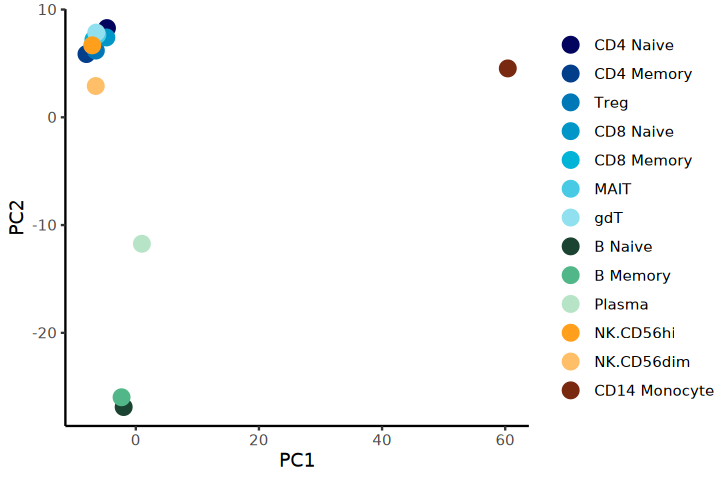

In [13]:
fig.size(4,6)
#pdf(file.path(fig_dir, "Fig2", glue("{stim_select}_PCA_Scatterplot.pdf")), height = 4, width = 6)
ggplot(pc_scores, aes(x = PC1, y = PC2, color = Subtype)) +
    geom_point(size = 4) +
    labs(x = "PC1", y = "PC2") +
    theme_classic() + 
    scale_color_manual(values=subtype_cols) + 
    theme(legend.title = element_blank()) 
dev.off()

### 2B. IFNa DEGs L1 Upset Plot

In [17]:
l1_degs_select <- l1_degs %>% filter(stim == stim_select & Significant == "Yes")
# separate up and down-reg genes as different features
l1_degs_select$gene_sign <- ifelse(l1_degs_select$median_log2FC > 0, paste0("+", l1_degs_select$gene),
                                                      paste0("-", l1_degs_select$gene))

In [18]:
upset_df <- l1_degs_select %>% 
        select(gene_sign, celltype) %>%
  mutate(value = TRUE) %>%
  distinct() %>%
  pivot_wider(
    names_from = celltype,
    values_from = value,
    values_fill = FALSE
  )

In [19]:
df_mod <- l1_degs_select %>% group_by(gene_sign) %>% summarise(log2FC = mean(median_log2FC)) 
    
upset_df$gene <- gsub("[-a+]", "", upset_df$gene_sign)

upset_df_final <- left_join(upset_df, df_mod[,c("gene_sign", "log2FC")])

Joining with `by = join_by(gene_sign)`


In [20]:
upset_df_final$Direction <- ifelse(upset_df_final$log2FC > 0, "Upreg", "Downreg")
upset_df_final$Direction <- factor(upset_df_final$Direction, levels = c("Upreg", "Downreg"))

In [21]:
# set grouping order of intersections on upset
intersection_list <- list(c("Monocyte"),c("Bcell"),c("NK"),c("Tcell"),
                    c("Bcell", "NK"),
                    c("Monocyte", "Bcell"),
                    c("NK", "Tcell"), c("Bcell", "NK", "Tcell"),
                    c("Bcell", "NK", "Tcell", "Monocyte"))

Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”


null device 
          1

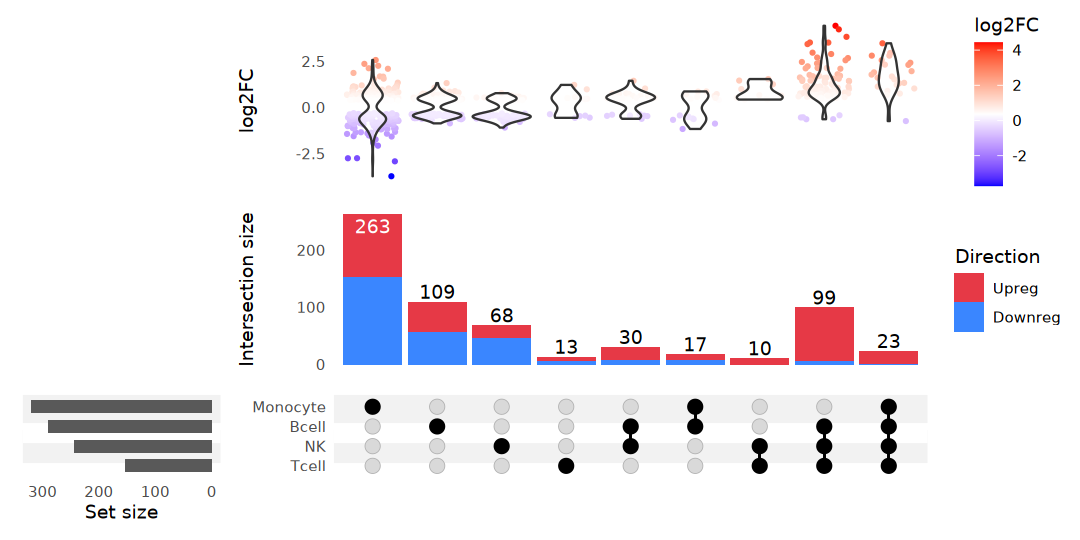

In [24]:
fig.size(4.5,9)
#pdf(file.path(fig_dir, "Fig2", glue("{stim}_Upset_Plot.pdf")), height = 4, width = 7)
ComplexUpset::upset(
        upset_df_final,
        celltypes,
        intersections=intersection_list,
        sort_intersections=FALSE,
        name = "",
    base_annotations=list(
        'Size'=(
            ComplexUpset::intersection_size(
                mode="exclusive_intersection",
                mapping=aes(fill=Direction),
                size=0,
                text=list(check_overlap=TRUE))+ scale_fill_manual(values=c(
            'Upreg'='#e63946', 'Downreg'='#3a86ff')
            )
        )
    ),
       annotations = list(
    'log2FC'=(
        ggplot(mapping=aes(y=log2FC)) + 
        geom_jitter(aes(color=log2FC), na.rm=T, size = 0.7) + 
        geom_violin(alpha=0.5, na.rm=T, scale = "area") + 
        #ggrepel::geom_text_repel(label = upset_df_label$label, force = 100) + 
        scale_color_gradientn(colors = c("blue", "white", "red"))
            )
        ),
        width_ratio = 0.25,
        min_size =10,
        themes=ComplexUpset::upset_default_themes(panel.grid = element_blank())
       
    )
dev.off()

### 2C. PCA IFN-L1 LogFC

In [7]:
stim_select <- "IFN-L1"

In [8]:
# pull significant ISGs for select stim
l2_sig_genes <- l2_degs %>% filter(stim == stim_select & Significant == "Yes") %>% pull(gene) %>% unique()

In [9]:
pca_df <- l2_degs %>% filter(stim == stim_select & gene %in% l2_sig_genes) %>%
    select(gene, median_log2FC, celltype) %>% 
    pivot_wider(names_from = celltype, values_from = median_log2FC) %>% 
    tibble::column_to_rownames("gene")

pca_df[is.na(pca_df)] <- 0

pca_df <- t(pca_df)

In [10]:
# run PCA and format output
pca_result <- prcomp(pca_df, scale = T, center = T)  

pc_scores <- as.data.frame(pca_result$x[, 1:2])

pc_scores$Sample <- rownames(pc_scores)
pc_scores$Stim <- pc_scores$Sample %>% stringr::str_extract("[^_]+$")
pc_scores$Subtype <- pc_scores$Sample %>% stringr::str_extract("[^_]*")

pc_scores$Subtype <- factor(pc_scores$Subtype, levels = subtypes)

null device 
          1

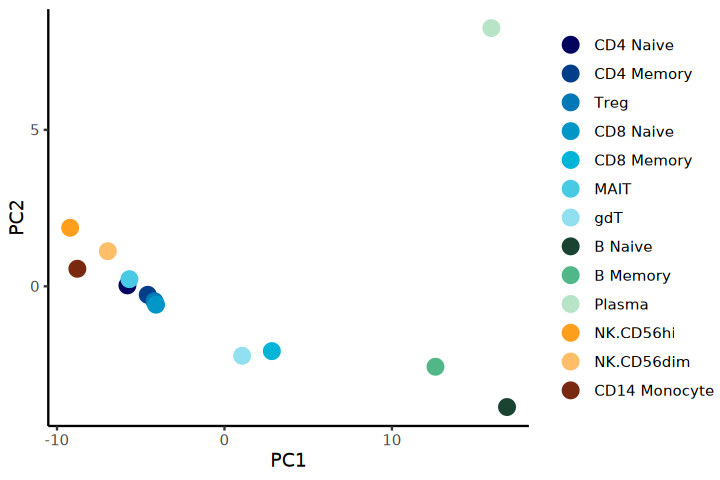

In [11]:
fig.size(4,6)
#pdf(file.path(fig_dir, "Fig2", glue("{stim_select}_PCA_Scatterplot.pdf")), height = 4, width = 6)
ggplot(pc_scores, aes(x = PC1, y = PC2, color = Subtype)) +
    geom_point(size = 4) +
    labs(x = "PC1", y = "PC2") +
    theme_classic() + 
    scale_color_manual(values=subtype_cols) + 
    theme(legend.title = element_blank()) 
dev.off()

### 2D. IFN-L1 Plasma vs Other B Cell Subsets ISGs Heatmap

In [12]:
# read-in plasma vs naive + memory most differential genes across subsets
bcell_subtypes <- c("B Naive", "B Memory", "Plasma")
plasma_ifnl_genes <- fread(file.path(wd, "DEGs", "Plasma_Cell_vs_Naive_Memory_Genes.csv")) %>% 
    pull(gene)

In [14]:
l2_degs_ifnl <- l2_degs %>% 
                    filter(gene %in% plasma_ifnl_genes[1:10] & stim == "IFN-L1" & celltype %in% bcell_subtypes)

In [33]:
HA <- ComplexHeatmap::HeatmapAnnotation(df = data.frame(Subtype = bcell_subtypes), 
                                        col = list(Subtype = c("B Naive" = "#1b4332", 
                                                               "B Memory" = "#52b788", 
                                                               "Plasma" = "#b7e4c7"
                  )))

In [34]:
# prepare matrix
mat <- l2_degs_ifnl %>% pivot_wider(!c(Significant, median_pval, stim),
                     names_from = celltype, values_from = median_log2FC) %>% tibble::column_to_rownames("gene") %>%
    as.matrix()
mat[is.na(mat)] <- 0

Warning message:
“Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
ℹ Please explicitly name `id_cols`, like `id_cols = !c(Significant,
  median_pval, stim)`.”


null device 
          1

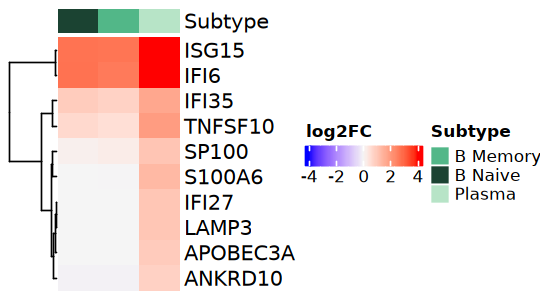

In [35]:
fig.size(2.5,4.5)
#pdf(file.path(fig_dir, "Fig2", glue("IFN-L1_Bcell_Plasma_Heatmap.pdf")), height = 2.5, width = 4.5)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray96", "red"))
ComplexHeatmap::Heatmap(mat, name = "log2FC", top_annotation = HA, 
                        show_row_names = T, show_column_names = F, col = col_fun, cluster_rows = T,
                        cluster_columns = F, 
                        cluster_column_slices = F,
                        column_title_rot = 90, 
                        heatmap_legend_param = list(legend_direction = "horizontal"))
dev.off()

### 2E. L1 Cell Type IFNa/b/l Venn Diagrams

In [36]:
l1_degs_sig <- l1_degs %>% filter(Significant == "Yes")

In [37]:
# create IFNa, IFNb, IFN-L1 venn diagram for each cell type
ggs <- lapply(celltypes, function(x){
    ifna <- l1_degs_sig %>% filter(stim == "IFNa" & celltype == x) %>% pull(gene) %>% unique()
    ifnb <- l1_degs_sig %>% filter(stim == "IFNb" & celltype == x) %>% pull(gene) %>% unique()
    ifnl <- l1_degs_sig %>% filter(stim == "IFN-L1" & celltype == x) %>% pull(gene) %>% unique()

    ls_degs <- list(IFNa = ifna,
                    IFNb = ifnb,
                    IFNL1 = ifnl)
    
    plot(euler(ls_degs, shape = "ellipse"), quantities = TRUE, label = F,
        list(fill = c("#4d9de0", "#e15554", "#3bb273"),
             alpha = 0.7),
         main = x)
    
    })

Warning message in colSums(id & !empty) == 0 | merged_sets:
“longer object length is not a multiple of shorter object length”


null device 
          1

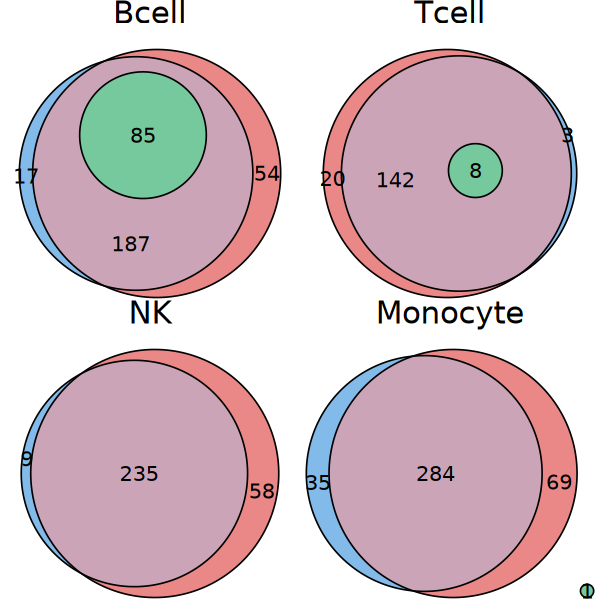

In [41]:
fig.size(5,5)
#pdf(file.path(fig_dir, "Fig2", glue("IFNa_IFNb_IFNL1_Venn_Diagrams.pdf")), height = 5, width = 5)
grid.arrange(grobs = ggs, ncol = 2)
dev.off()

### 2F. IFNa/b and IFNa/l LogFC Correlations

In [43]:
# pull all L2 ISGs and format
l2_degs_sig <- l2_degs %>% filter(Significant == "Yes") %>% pull(gene)
l2_wide <- l2_degs %>% 
    filter(gene %in% l2_degs_sig) %>% 
    select(gene, celltype, stim, median_log2FC) %>% 
    pivot_wider(names_from = stim, values_from = median_log2FC)

#### IFNa vs IFNb

Warning message:
“Removed 300 rows containing missing values or values outside the scale range
(`geom_point()`).”


null device 
          1

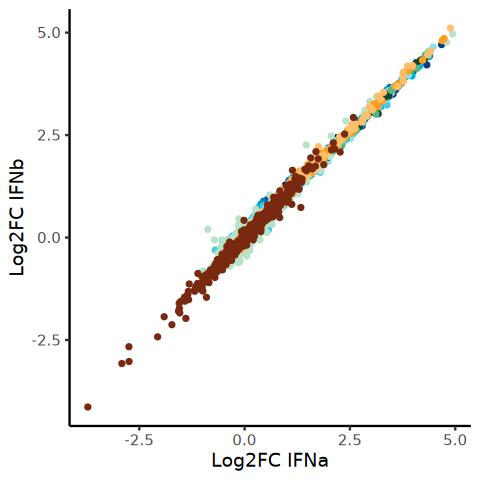

In [44]:
fig.size(4,4)
#pdf(file.path(fig_dir, "Fig2", "IFNa_IFNb_LogFC_Scatterplot.pdf"), height = 4, width = 4.3)
ggplot(l2_wide, aes(x=IFNa, y=IFNb, color = celltype)) + 
        geom_point(size = 1) + 
        labs(x = "Log2FC IFNa", y = "Log2FC IFNb") + 
        #xlim(-5, 5) + 
        #ylim(-5, 5) + 
        theme_classic() + 
        #ggrepel::geom_text_repel(aes(label = label, color = subtype), max.overlaps = 100) + 
        scale_color_manual(values=subtype_cols) + 
        theme(plot.title = element_text(hjust = 0.5)) + 
        theme(legend.position = "none")
dev.off()

In [ ]:
# calculate linear fit slope per cell type
slope_df <- l2_wide %>% 
  group_by(celltype) %>% 
  summarise(
    
    Intercept = lm(IFNb ~ IFNa, data = cur_data())$coefficients[1],
    Slope = lm(IFNb ~ IFNa, data = cur_data())$coefficients[2],
    Slope_Pval = summary(lm(IFNb ~ IFNa, data = cur_data()))$coefficients[2, 4],
    CI_low = confint(lm(IFNb ~ IFNa, data = cur_data()))[2, 1],
    CI_high = confint(lm(IFNb ~ IFNa, data = cur_data()))[2, 2]
  )

null device 
          1

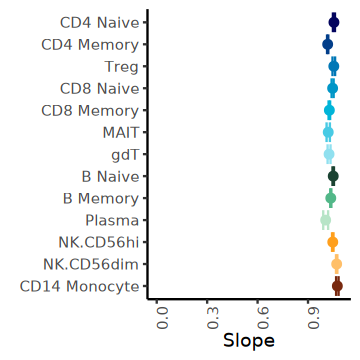

In [46]:
fig.size(3,3)
#pdf(file.path(fig_dir, "Fig2", "IFNa_IFNb_LogFC_Correlation_Slope_Error.pdf"), height = 4, width = 3)
slope_df$celltype <- factor(slope_df$celltype, levels = rev(subtypes))
slope_df <- slope_df %>% arrange(celltype)

ggplot(data=slope_df, aes(x=Slope, y=celltype, color = celltype)) +
  geom_point(aes(x=Slope), size=2) +
  geom_errorbarh(aes(xmin=CI_low, xmax=CI_high)) + 
    theme_classic() + 
    xlim(0,1.1) + 
    scale_color_manual(values=rev(subtype_cols)) + 
    labs(x = "Slope", y = "") + 
    theme(axis.text.x = element_text(angle = 90), legend.position = "none") 
dev.off()

#### IFNa vs IFN-L1

Warning message:
“Removed 477 rows containing missing values or values outside the scale range
(`geom_point()`).”


null device 
          1

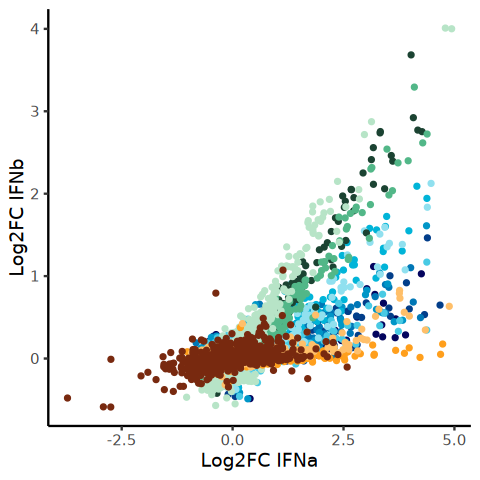

In [47]:
fig.size(4,4)
#pdf(file.path(fig_dir, "Fig2", "IFNa_IFN-L1_LogFC_Scatterplot.pdf"), height = 4, width = 4.3)
ggplot(l2_wide, aes(x=IFNa, y=`IFN-L1`, color = celltype)) + 
        geom_point(size = 1) + 
        labs(x = "Log2FC IFNa", y = "Log2FC IFNb") + 
        #xlim(-5, 5) + 
        #ylim(-5, 5) + 
        theme_classic() + 
        #ggrepel::geom_text_repel(aes(label = label, color = subtype), max.overlaps = 100) + 
        scale_color_manual(values=subtype_cols) + 
        theme(plot.title = element_text(hjust = 0.5)) + 
        theme(legend.position = "none")
dev.off()

In [38]:
slope_df <- l2_wide %>% 
  group_by(celltype) %>% 
  summarise(
    
    Intercept = lm(`IFN-L1` ~ IFNa, data = cur_data())$coefficients[1],
    Slope = lm(`IFN-L1` ~ IFNa, data = cur_data())$coefficients[2],
    Slope_Pval = summary(lm(`IFN-L1` ~ IFNa, data = cur_data()))$coefficients[2, 4],
    CI_low = confint(lm(`IFN-L1` ~ IFNa, data = cur_data()))[2, 1],
    CI_high = confint(lm(`IFN-L1` ~ IFNa, data = cur_data()))[2, 2]
  )

null device 
          1

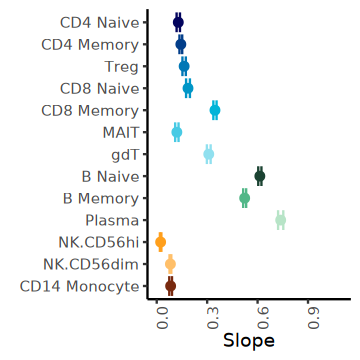

In [41]:
fig.size(3,3)
#pdf(file.path(fig_dir, "Fig2", "IFNa_IFN-L1_Correlation_Slope_Error.pdf"), height = 4, width = 3)
slope_df$celltype <- factor(slope_df$celltype, levels = rev(subtypes))
slope_df <- slope_df %>% arrange(celltype)

ggplot(data=slope_df, aes(x=Slope, y=celltype, color = celltype)) +
  geom_point(aes(x=Slope), size=2) +
  geom_errorbarh(aes(xmin=CI_low, xmax=CI_high)) + 
    theme_classic() + 
    xlim(0,1.1) + 
    scale_color_manual(values=rev(subtype_cols)) + 
    labs(x = "Slope", y = "") + 
    theme(axis.text.x = element_text(angle = 90), legend.position = "none") 
dev.off()

### 2G. IFNa IFN-L1 Comparison Bubbleplot and Boxplot

In [ ]:
# read in full cell type object
so <- readRDS(file.path(wd, "seurat_objects", "so_complete2.rds"))

In [42]:
stims <- c("none", "IFN-L1", "IFNa")
ifnl_subtypes <- c("Plasma", "B Naive", "B Memory", "CD8 Memory", "gdT")

In [13]:
# pull genes with highest mean FC across IFN-L1 responding subsets
ifnl_genes <- l2_degs %>% 
    filter(Significant == "Yes" & stim == "IFN-L1" & celltype %in% ifnl_subtypes) %>% 
    group_by(gene) %>% summarise(mean = mean(median_log2FC)) %>% arrange(-mean) %>% pull(gene)

In [17]:
# subset seurat object to responding cell types
sub <- so %>% subset(Celltype %in% c("Bcell", "Tcell") & Description %in% stims)

In [ ]:
# group together non-responding T cell subset as "Other T"
subtypes_select <- c("Plasma", "Naive", "Memory", "CD8 Memory", "gdT", "Other T")

# create new Subtype category with "Other T"
sub$Subtype1 <- ifelse(sub$Subtype %in% subtypes_select, 
                       "Other T", sub$Subtype)
sub$Subtype1_Description <- paste(sub$Subtype1, sub$Description, sep = "-")    

In [43]:
# refactor variable to ensure correct order
order_comb <- paste(rep(subtypes_select, each = 3), rep(stims, 3), sep = "_")
sub$Subtype1_Description <- factor(sub$Subtype1_Description, levels = order_comb)

null device 
          1

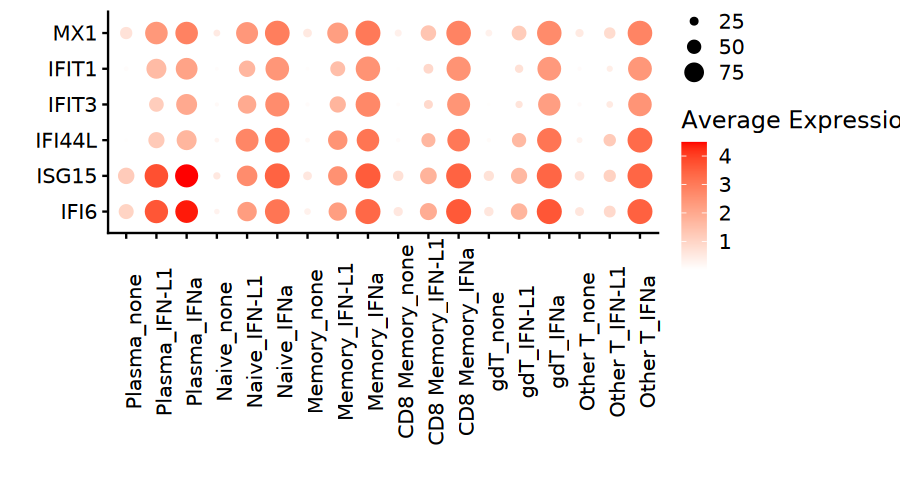

In [45]:
fig.size(4,7.5)
#pdf(file.path(fig_dir, "Fig2", "IFNL1_BubblePlot.pdf"), height = 4, width = 7.5)
DotPlot(sub, features = ifnl_genes[1:6], 
        cols = c("white", "red"), 
        group.by = "Subtype1_Description", 
        scale = F) + theme(axis.text.x = element_text(angle = 90)) + labs(x = "", y = "") + 
        coord_flip()
dev.off()

In [76]:
# get average expression of all IFN-L1 ISGs across stims and responding subsets
avgexp <- AverageExpression(sub, features = ifnl_genes, group.by = "Subtype1_Description", return.seurat = T)

avgexp_df <- avgexp@assays$RNA@layers$data %>% as.data.frame() 
rownames(avgexp_df) <- rownames(avgexp@assays$RNA@features)
colnames(avgexp_df) <- order_comb

avgexp_df <- avgexp_df %>%
                tibble::rownames_to_column("gene") %>%
                pivot_longer(!gene, names_to = "celltype_stim", values_to = "Expression")
avgexp_df$celltype_stim <- factor(avgexp_df$celltype_stim, levels = order_comb) 

Centering and scaling data matrix



In [77]:
avgexp_df$stim <- avgexp_df$celltype_stim %>% stringr::str_extract("[^_]+$") 

null device 
          1

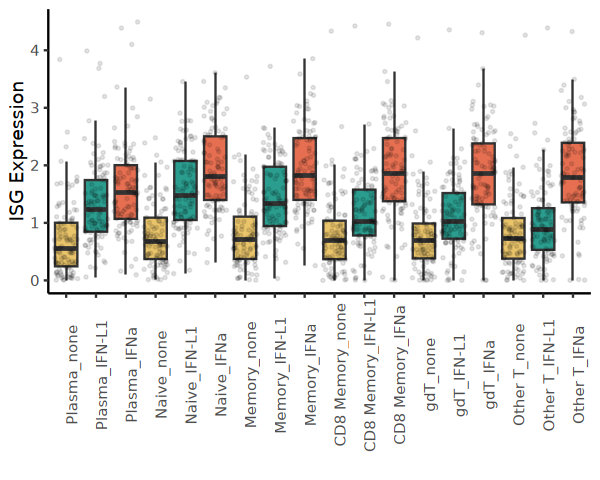

In [66]:
fig.size(4,5)
#pdf(file.path(fig_dir, "Fig2", "IFNL1_Expression_Boxplots.pdf"), height = 2.5, width = 5)
ggplot(avgexp_df, aes(x=celltype, y=Expression, fill = stim)) + 
  geom_boxplot(alpha = 1, outlier.shape = NA) + 
    geom_jitter(aes(fill = stim), size = 0.5, alpha = 0.1) + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90),
         legend.position = "none") + 
    scale_fill_manual(values=c("#e9c46a", "#2a9d8f", "#e76f51")) + 
    labs(x = "", y = "ISG Expression")
dev.off()